<a href="https://colab.research.google.com/github/Rohan-1103/Data-Science/blob/main/DL/cats_v_dogs_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install and Download dataset

In [66]:
!pip install -q kagglehub

import kagglehub
import os
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import cv2
import matplotlib.pyplot as plt

# Download dataset
base_path = kagglehub.dataset_download("tongpython/cat-and-dog")

# Correct nested paths
train_dir = base_path + "/training_set/training_set"
test_dir = base_path + "/test_set/test_set"

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Train folders: ['dogs', 'cats']
Test folders: ['dogs', 'cats']


### Load Dataset (Auto Split)

In [67]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


### Normalize & Optimize

In [68]:
def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)

### CNN Model

In [69]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

### Compile and Train

In [70]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 107ms/step - accuracy: 0.5253 - loss: 5.2348 - val_accuracy: 0.5096 - val_loss: 1.4415
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.5133 - loss: 0.7987 - val_accuracy: 0.5601 - val_loss: 0.6924
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.5096 - loss: 0.6999 - val_accuracy: 0.5121 - val_loss: 0.6901
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.5439 - loss: 0.6820 - val_accuracy: 0.5250 - val_loss: 0.6814
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.5405 - loss: 0.6909 - val_accuracy: 0.6149 - val_loss: 0.6473
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.5580 - loss: 0.6716 - val_accuracy: 0.6495 - val_loss: 0.6315
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.5743 - loss: 0.6755 - val_accuracy: 0.6569 - val_loss: 0.6331
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.6092 - loss: 0.6495 -

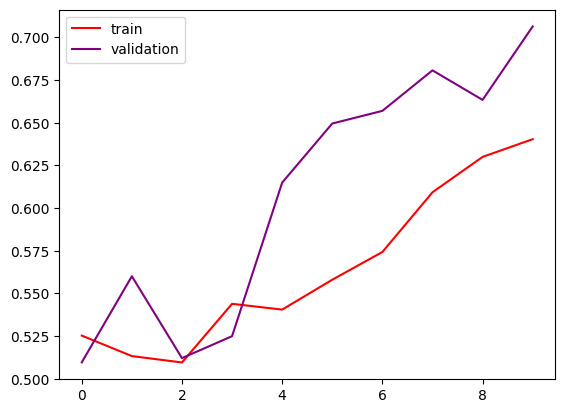

In [71]:
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'purple', label = 'validation')
plt.legend()
plt.show()

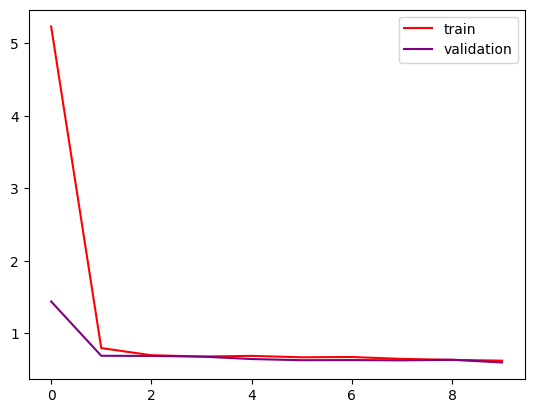

In [72]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'purple', label = 'validation')
plt.legend()
plt.show()

Saving IMG-20260103-WA0007.jpg to IMG-20260103-WA0007 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Dog 🐶


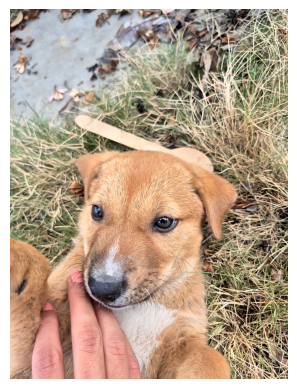

In [79]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

test_img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

test_img = cv2.resize(test_img, (256,256))
test_input = test_img.reshape((1,256,256,3)) / 255.0

prediction = model.predict(test_input)

if prediction[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")